# Fine-tune DINOv2 for 252×252 object detection

This notebook uses a pretrained **DINOv2 ViT-S/14** backbone inside **Faster R-CNN**. Images are resized to 252×252 only when needed; images already at 252×252 are left untouched. Bounding boxes are scaled whenever an image is resized.

This version reads the existing `runs_v2/crops` folder directly. It reconstructs one pseudo bounding box per crop from `runs_v2/tracks.db`, then automatically creates an 80/20 train/validation split grouped by tracked object. No images are moved or copied. The final sections run the trained detector on a webcam or video file in real time.

## 1. Install dependencies

Run this once if the environment does not already contain these packages. A CUDA-enabled PyTorch installation is strongly recommended for training and real-time inference.

In [1]:
# Uncomment and run if needed. Install the CUDA build of PyTorch separately when appropriate.
# %pip install -U torch torchvision pycocotools torchmetrics[detection] opencv-python matplotlib pillow tqdm

In [2]:
from collections import OrderedDict
from pathlib import Path
import json
import math
import os
import random
import re
import shutil
import sqlite3
import time

import cv2
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset, Subset
from torchvision.models.detection import FasterRCNN
from torchvision.models.detection.anchor_utils import AnchorGenerator
from torchvision.models.detection.transform import GeneralizedRCNNTransform
from torchvision.ops import MultiScaleRoIAlign
from torchvision.transforms import InterpolationMode
from torchvision.transforms import functional as TF
from torchmetrics.detection.mean_ap import MeanAveragePrecision
from tqdm.auto import tqdm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMAGE_SIZE = 252       # 18 × DINOv2's 14-pixel patch size
PATCH_SIZE = 14
MODEL_NAME = "dinov2_vits14"  # ViT-S is the best starting point for real-time use
BATCH_SIZE = 2
NUM_WORKERS = 0        # Increase on Linux; 0 is the safest setting in Windows notebooks
EPOCHS = 10
BACKBONE_LR = 1e-5
DETECTOR_LR = 1e-4
WEIGHT_DECAY = 1e-4
UNFREEZE_LAST_N_BLOCKS = 2
VALIDATION_FRACTION = 0.20
TRACK_CUTOUT_CONTEXT = 1.25  # Must match the crop-generation notebook
OBJECT_CLASS_NAME = "tracked_object"
CHECKPOINT_DIR = Path("checkpoints/dinov2_fasterrcnn_252")
PROGRESS_CHECKPOINT_PATH = CHECKPOINT_DIR / "progress_latest.pt"
BEST_CHECKPOINT_PATH = CHECKPOINT_DIR / "best_model.pt"
HISTORY_PATH = CHECKPOINT_DIR / "history.json"
STATUS_PATH = CHECKPOINT_DIR / "training_status.json"
CHECKPOINT_EVERY_N_BATCHES = 500   # Rolling mid-epoch recovery checkpoint
KEEP_LAST_N_EPOCH_CHECKPOINTS = 2  # Bounds disk use; best + progress are separate
MIN_FREE_DISK_GB = 1.0             # Skip optional saves before exhausting the drive
AUTO_RESUME = True

print(f"Using {DEVICE}")

Using cpu


c:\Users\vitya\Fvscode\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Automatic dataset preparation from `runs_v2/crops`

The crop names contain their source clip, track ID, and frame number. The matching rows in `runs_v2/tracks.db` provide the original detection aspect ratio, allowing the notebook to reconstruct the centered object box inside each tracking cutout.

The split is performed by `(clip, track_id)`, not by individual image. Consequently, every crop from one tracked object stays entirely in either training or validation. This prevents nearly identical neighboring video frames from leaking across the split. The split is deterministic for `SEED = 42` and does not alter the crop folder.

> **Important:** these are automatically reconstructed, single-class pseudo-labels. Every crop is already centered on a motion-tracker proposal, so this trains a generic `tracked_object` detector rather than named semantic classes. Validation measures performance on held-out crops; it does not guarantee full-frame video performance. For a production detector, manually labeled full video frames—including background-only frames—are still the strongest training data.

In [3]:
def resize_to_252_if_needed(image, boxes):
    """Return a 252×252 PIL image and scaled xyxy boxes.

    No interpolation is performed when the input is already exactly 252×252.
    """
    original_width, original_height = image.size
    if (original_height, original_width) == (IMAGE_SIZE, IMAGE_SIZE):
        return image, boxes

    image = TF.resize(
        image,
        [IMAGE_SIZE, IMAGE_SIZE],
        interpolation=InterpolationMode.BILINEAR,
        antialias=True,
    )
    if boxes.numel() > 0:
        scale = boxes.new_tensor([
            IMAGE_SIZE / original_width,
            IMAGE_SIZE / original_height,
            IMAGE_SIZE / original_width,
            IMAGE_SIZE / original_height,
        ])
        boxes = boxes * scale
    return image, boxes


CROP_NAME_PATTERN = re.compile(r"^(?P<clip>.+)_T(?P<track>\d+)_f(?P<frame>\d+)$")
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}


def discover_crop_records(crop_dir, database_path, context=TRACK_CUTOUT_CONTEXT):
    """Match every crop to its tracker row without changing any files."""
    crop_dir = Path(crop_dir)
    database_path = Path(database_path)
    if not crop_dir.is_dir():
        raise FileNotFoundError(f"Crop folder not found: {crop_dir.resolve()}")
    if not database_path.is_file():
        raise FileNotFoundError(f"Tracking database not found: {database_path.resolve()}")

    wanted = {}
    invalid_names = []
    for path in crop_dir.iterdir():
        if not path.is_file() or path.suffix.lower() not in IMAGE_EXTENSIONS:
            continue
        match = CROP_NAME_PATTERN.match(path.stem)
        if match is None:
            invalid_names.append(path.name)
            continue
        key = (match.group("clip"), int(match.group("track")), int(match.group("frame")))
        wanted[key] = path

    if invalid_names:
        preview = ", ".join(invalid_names[:5])
        raise ValueError(f"Found {len(invalid_names)} crop names that cannot be parsed, e.g. {preview}")
    if not wanted:
        raise RuntimeError(f"No supported images found in {crop_dir.resolve()}")

    records = []
    matched_keys = set()
    with sqlite3.connect(database_path) as connection:
        clip_to_stem = {name: Path(name).stem for (name,) in connection.execute("SELECT name FROM clips")}
        rows = connection.execute(
            "SELECT clip_name, track_id, frame_idx, x1, y1, x2, y2 FROM detections"
        )
        for clip_name, track_id, frame_idx, x1, y1, x2, y2 in rows:
            clip_stem = clip_to_stem.get(clip_name, Path(clip_name).stem)
            key = (clip_stem, int(track_id), int(frame_idx))
            path = wanted.get(key)
            if path is None:
                continue
            box_width = max(float(x2) - float(x1), 1.0)
            box_height = max(float(y2) - float(y1), 1.0)
            longest_side = max(box_width, box_height)
            records.append({
                "path": path,
                "group": (clip_stem, int(track_id)),
                "box_width_fraction": box_width / (longest_side * context),
                "box_height_fraction": box_height / (longest_side * context),
            })
            matched_keys.add(key)

    missing = len(wanted) - len(matched_keys)
    if missing:
        missing_examples = [str(wanted[key].name) for key in wanted.keys() - matched_keys][:5]
        raise RuntimeError(f"{missing} crops have no matching database detection, e.g. {missing_examples}")
    records.sort(key=lambda record: record["path"].name)
    return records


def split_records_by_track(records, validation_fraction=VALIDATION_FRACTION, seed=SEED):
    groups = sorted({record["group"] for record in records})
    if len(groups) < 2:
        raise RuntimeError("At least two distinct tracks are required for a train/validation split")
    generator = random.Random(seed)
    generator.shuffle(groups)
    validation_group_count = round(len(groups) * validation_fraction)
    validation_group_count = min(max(validation_group_count, 1), len(groups) - 1)
    validation_groups = set(groups[:validation_group_count])
    train_records = [record for record in records if record["group"] not in validation_groups]
    validation_records = [record for record in records if record["group"] in validation_groups]
    return train_records, validation_records


class TrackingCropDataset(Dataset):
    def __init__(self, records, train=False):
        self.records = list(records)
        self.train = train

    def __len__(self):
        return len(self.records)

    def __getitem__(self, index):
        record = self.records[index]
        image = Image.open(record["path"]).convert("RGB")
        width, height = image.size
        center_x, center_y = (width - 1) / 2.0, (height - 1) / 2.0
        box_width = width * record["box_width_fraction"]
        box_height = height * record["box_height_fraction"]
        boxes = torch.tensor([[
            max(0.0, center_x - box_width / 2.0),
            max(0.0, center_y - box_height / 2.0),
            min(float(width), center_x + box_width / 2.0),
            min(float(height), center_y + box_height / 2.0),
        ]], dtype=torch.float32)
        image, boxes = resize_to_252_if_needed(image, boxes)

        if self.train and random.random() < 0.5:
            image = TF.hflip(image)
            old_x1 = boxes[:, 0].clone()
            old_x2 = boxes[:, 2].clone()
            boxes[:, 0] = IMAGE_SIZE - old_x2
            boxes[:, 2] = IMAGE_SIZE - old_x1

        labels = torch.ones((1,), dtype=torch.int64)
        image_tensor = TF.pil_to_tensor(image).float().div(255.0)
        area = (boxes[:, 2] - boxes[:, 0]) * (boxes[:, 3] - boxes[:, 1])
        target = {
            "boxes": boxes,
            "labels": labels,
            "image_id": torch.tensor(index, dtype=torch.int64),
            "area": area,
            "iscrowd": torch.zeros((1,), dtype=torch.int64),
        }
        return image_tensor, target


def detection_collate(batch):
    return tuple(zip(*batch))

In [4]:
CROP_DIR = Path("runs_v2/crops")
TRACK_DATABASE = Path("runs_v2/tracks.db")

all_records = discover_crop_records(CROP_DIR, TRACK_DATABASE)
train_records, validation_records = split_records_by_track(all_records)
train_dataset = TrackingCropDataset(train_records, train=True)
val_dataset = TrackingCropDataset(validation_records, train=False)

def make_train_loader(epoch, completed_batches=0):
    """Build a deterministic epoch order and optionally resume partway through it."""
    generator = torch.Generator().manual_seed(SEED + int(epoch))
    indices = torch.randperm(len(train_dataset), generator=generator).tolist()
    first_remaining_image = int(completed_batches) * BATCH_SIZE
    remaining_dataset = Subset(train_dataset, indices[first_remaining_image:])
    return DataLoader(
        remaining_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS,
        collate_fn=detection_collate, pin_memory=torch.cuda.is_available(),
    )

val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS,
    collate_fn=detection_collate, pin_memory=torch.cuda.is_available(),
)

NUM_CLASSES = 2  # background + one tracked-object class
LABEL_TO_NAME = {1: OBJECT_CLASS_NAME}
train_track_count = len({record["group"] for record in train_records})
validation_track_count = len({record["group"] for record in validation_records})
print(f"Discovered images: {len(all_records):,}")
print(f"Train images: {len(train_dataset):,}")
print(f"Validation images: {len(val_dataset):,}")
print(f"Train tracks: {train_track_count:,}")
print(f"Validation tracks: {validation_track_count:,}")
print(f"Classes: {LABEL_TO_NAME}")

Discovered images: 141,852
Train images: 113,560
Validation images: 28,292
Train tracks: 16,939
Validation tracks: 4,235
Classes: {1: 'tracked_object'}


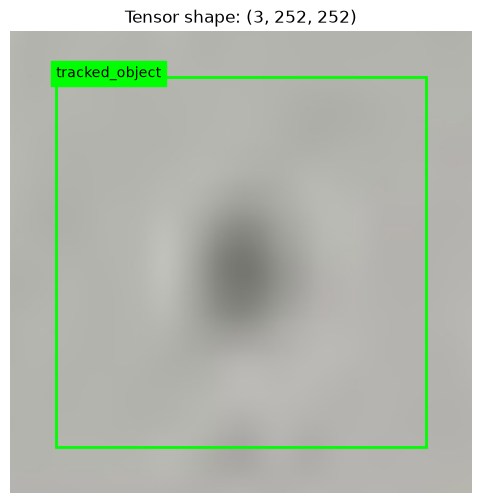

In [5]:
# Sanity-check one resized image and its boxes before training.
image, target = train_dataset[0]
figure, axis = plt.subplots(figsize=(6, 6))
axis.imshow(image.permute(1, 2, 0))
for box, label in zip(target["boxes"], target["labels"]):
    x1, y1, x2, y2 = box.tolist()
    axis.add_patch(plt.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, color="lime", linewidth=2))
    axis.text(x1, y1, LABEL_TO_NAME[int(label)], color="black", backgroundcolor="lime")
axis.set_title(f"Tensor shape: {tuple(image.shape)}")
axis.axis("off");

## 3. DINOv2 backbone and Faster R-CNN

The first run downloads pretrained weights from Meta's official DINOv2 repository through `torch.hub`. The custom detector transform normalizes and batches tensors but deliberately refuses to resize them; this guarantees that images already made 252×252 by the dataset are not interpolated again.

In [6]:
class NoResizeDetectionTransform(GeneralizedRCNNTransform):
    def resize(self, image, target=None):
        if tuple(image.shape[-2:]) != (IMAGE_SIZE, IMAGE_SIZE):
            raise ValueError(
                f"Detector expected {IMAGE_SIZE}×{IMAGE_SIZE}, got {tuple(image.shape[-2:])}. "
                "Use resize_to_252_if_needed first."
            )
        return image, target


class DINOv2Backbone(nn.Module):
    def __init__(self, model_name=MODEL_NAME, unfreeze_last_n_blocks=2):
        super().__init__()
        self.dino = torch.hub.load("facebookresearch/dinov2", model_name)
        self.out_channels = self.dino.embed_dim
        self.patch_size = PATCH_SIZE

        # Freeze most of the pretrained representation to reduce memory use and overfitting.
        for parameter in self.dino.parameters():
            parameter.requires_grad = False
        if unfreeze_last_n_blocks > 0:
            for block in list(self.dino.blocks)[-unfreeze_last_n_blocks:]:
                for parameter in block.parameters():
                    parameter.requires_grad = True
            for parameter in self.dino.norm.parameters():
                parameter.requires_grad = True

    def forward(self, images):
        features = self.dino.forward_features(images)["x_norm_patchtokens"]
        grid_height = images.shape[-2] // self.patch_size
        grid_width = images.shape[-1] // self.patch_size
        expected_tokens = grid_height * grid_width
        if features.shape[1] != expected_tokens:
            raise RuntimeError(f"Expected {expected_tokens} patch tokens, got {features.shape[1]}")
        features = features.transpose(1, 2).reshape(
            images.shape[0], self.out_channels, grid_height, grid_width
        )
        return OrderedDict({"0": features})


def build_detector(num_classes, unfreeze_last_n_blocks=UNFREEZE_LAST_N_BLOCKS):
    backbone = DINOv2Backbone(MODEL_NAME, unfreeze_last_n_blocks)
    anchor_generator = AnchorGenerator(
        sizes=((16, 32, 64, 128, 256),),
        aspect_ratios=((0.5, 1.0, 2.0),),
    )
    roi_pooler = MultiScaleRoIAlign(featmap_names=["0"], output_size=7, sampling_ratio=2)
    detector = FasterRCNN(
        backbone=backbone,
        num_classes=num_classes,
        rpn_anchor_generator=anchor_generator,
        box_roi_pool=roi_pooler,
        min_size=IMAGE_SIZE,
        max_size=IMAGE_SIZE,
    )
    detector.transform = NoResizeDetectionTransform(
        min_size=IMAGE_SIZE,
        max_size=IMAGE_SIZE,
        image_mean=[0.485, 0.456, 0.406],
        image_std=[0.229, 0.224, 0.225],
        size_divisible=PATCH_SIZE,
    )
    return detector


model = build_detector(NUM_CLASSES).to(DEVICE)
trainable = sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)
total = sum(parameter.numel() for parameter in model.parameters())
print(f"Trainable parameters: {trainable:,} / {total:,}")

Using cache found in C:\Users\vitya/.cache\torch\hub\facebookresearch_dinov2_main
C:\Users\vitya/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
C:\Users\vitya/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
C:\Users\vitya/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


Trainable parameters: 25,236,053 / 43,741,397


In [7]:
backbone_parameters = [p for p in model.backbone.parameters() if p.requires_grad]
backbone_parameter_ids = {id(p) for p in backbone_parameters}
detector_parameters = [
    p for p in model.parameters() if p.requires_grad and id(p) not in backbone_parameter_ids
]
optimizer = torch.optim.AdamW(
    [
        {"params": backbone_parameters, "lr": BACKBONE_LR},
        {"params": detector_parameters, "lr": DETECTOR_LR},
    ],
    weight_decay=WEIGHT_DECAY,
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
use_amp = DEVICE.type == "cuda"
scaler = torch.amp.GradScaler("cuda", enabled=use_amp)

## 4. Fine-tuning, validation, and automatic recovery

Training writes the following under `checkpoints/dinov2_fasterrcnn_252/`:

- `progress_latest.pt`: rolling model, optimizer, scheduler, scaler, epoch, and batch state
- `epoch_XXX.pt`: completed-epoch snapshots (only the newest configured number are retained)
- `best_model.pt`: the best validation model for deployment
- `history.json`: loss and mAP for every completed epoch
- `training_status.json`: lightweight human-readable current progress and free disk space

Restarting the training cell automatically resumes from the newest valid progress or epoch checkpoint. Pressing Stop/Interrupt also attempts an immediate recovery save. Writes use temporary files and atomic replacement, so a failed save cannot overwrite the previous good checkpoint.

In [8]:
def move_target_to_device(target, device):
    return {key: value.to(device) if torch.is_tensor(value) else value for key, value in target.items()}


def train_one_epoch(
    model, loader, optimizer, scaler, device, epoch, total_batches,
    completed_batches=0, initial_loss_sum=0.0, checkpoint_callback=None, progress_state=None,
):
    model.train()
    running_loss = float(initial_loss_sum)
    progress = tqdm(
        loader, desc=f"Epoch {epoch}/{EPOCHS}", leave=False,
        initial=completed_batches, total=total_batches,
    )
    for local_batch_index, (images, targets) in enumerate(loader):
        images = [image.to(device, non_blocking=True) for image in images]
        targets = [move_target_to_device(target, device) for target in targets]
        optimizer.zero_grad(set_to_none=True)

        with torch.autocast(device_type=device.type, dtype=torch.float16, enabled=scaler.is_enabled()):
            losses = model(images, targets)
            total_loss = sum(losses.values())

        if not torch.isfinite(total_loss):
            raise FloatingPointError(f"Non-finite loss: {float(total_loss)}; components: {losses}")
        scaler.scale(total_loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(
            [p for p in model.parameters() if p.requires_grad], max_norm=5.0
        )
        scaler.step(optimizer)
        scaler.update()
        running_loss += total_loss.item()
        completed = completed_batches + local_batch_index + 1
        if progress_state is not None:
            progress_state.update(completed_batches=completed, epoch_loss_sum=running_loss)
        progress.update(1)
        progress.set_postfix(loss=f"{total_loss.item():.4f}")
        if (
            checkpoint_callback is not None
            and CHECKPOINT_EVERY_N_BATCHES > 0
            and completed % CHECKPOINT_EVERY_N_BATCHES == 0
        ):
            checkpoint_callback(completed, running_loss)

    progress.close()
    return running_loss / max(total_batches, 1), running_loss


@torch.inference_mode()
def evaluate_map(model, loader, device):
    model.eval()
    metric = MeanAveragePrecision(box_format="xyxy", iou_type="bbox")
    for images, targets in tqdm(loader, desc="Validation", leave=False):
        outputs = model([image.to(device, non_blocking=True) for image in images])
        predictions = [
            {key: value.detach().cpu() for key, value in output.items() if key in {"boxes", "scores", "labels"}}
            for output in outputs
        ]
        ground_truth = [
            {"boxes": target["boxes"].cpu(), "labels": target["labels"].cpu()}
            for target in targets
        ]
        metric.update(predictions, ground_truth)
    return metric.compute()


In [ ]:
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)


def available_disk_gb():
    return shutil.disk_usage(CHECKPOINT_DIR.resolve()).free / (1024 ** 3)


def estimated_checkpoint_bytes():
    existing = [path.stat().st_size for path in CHECKPOINT_DIR.glob("*.pt") if path.is_file()]
    return max(existing, default=0)


def atomic_torch_save(payload, destination):
    """Write to a temporary file, then atomically replace the destination."""
    destination = Path(destination)
    destination.parent.mkdir(parents=True, exist_ok=True)
    temporary = destination.with_name(destination.name + ".tmp")
    estimate = estimated_checkpoint_bytes()
    free_bytes = shutil.disk_usage(destination.parent.resolve()).free
    reserve_bytes = int(MIN_FREE_DISK_GB * 1024 ** 3)
    if estimate and free_bytes < estimate + reserve_bytes:
        print(
            f"WARNING: skipped {destination.name}; only {free_bytes / 1024**3:.2f} GB free. "
            f"The previous good checkpoint is unchanged."
        )
        return False
    try:
        if temporary.exists():
            temporary.unlink()  # Remove only a stale interrupted temp checkpoint.
        torch.save(payload, temporary)
        os.replace(temporary, destination)
        return True
    except (OSError, RuntimeError) as error:
        if temporary.exists():
            temporary.unlink()
        print(f"WARNING: checkpoint save failed ({error}). Previous checkpoints are intact.")
        return False


def atomic_json_save(payload, destination):
    destination = Path(destination)
    temporary = destination.with_name(destination.name + ".tmp")
    try:
        temporary.write_text(json.dumps(payload, indent=2), encoding="utf-8")
        os.replace(temporary, destination)
    except OSError as error:
        if temporary.exists():
            temporary.unlink()
        print(f"WARNING: could not update {destination.name}: {error}")


def build_recovery_state(epoch, completed_batches, epoch_loss_sum, best_map, history):
    return {
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "scheduler_state": scheduler.state_dict(),
        "scaler_state": scaler.state_dict(),
        "epoch": int(epoch),
        "completed_batches": int(completed_batches),
        "epoch_loss_sum": float(epoch_loss_sum),
        "best_map": float(best_map),
        "history": list(history),
        "model_name": MODEL_NAME,
        "num_classes": NUM_CLASSES,
        "label_to_name": LABEL_TO_NAME,
        "image_size": IMAGE_SIZE,
        "batch_size": BATCH_SIZE,
        "train_image_count": len(train_dataset),
    }


def save_training_status(epoch, completed_batches, total_batches, best_map, message):
    atomic_json_save({
        "epoch": int(epoch),
        "epochs_requested": EPOCHS,
        "completed_batches": int(completed_batches),
        "total_batches": int(total_batches),
        "best_map": float(best_map) if math.isfinite(best_map) else None,
        "free_disk_gb": round(available_disk_gb(), 3),
        "message": message,
    }, STATUS_PATH)


def prune_old_epoch_checkpoints():
    snapshots = sorted(CHECKPOINT_DIR.glob("epoch_*.pt"))
    keep = max(int(KEEP_LAST_N_EPOCH_CHECKPOINTS), 0)
    old_snapshots = snapshots[:-keep] if keep else snapshots
    for old_path in old_snapshots:
        try:
            old_path.unlink()
            print(f"Removed old rolling snapshot: {old_path.name}")
        except OSError as error:
            print(f"WARNING: could not remove {old_path.name}: {error}")


best_map = float("-inf")
history = []
start_epoch = 1
resume_completed_batches = 0
resume_epoch_loss_sum = 0.0

resume_candidates = [PROGRESS_CHECKPOINT_PATH] + sorted(CHECKPOINT_DIR.glob("epoch_*.pt"))
resume_candidates = [path for path in resume_candidates if path.exists()]
if AUTO_RESUME and resume_candidates:
    resume_path = max(resume_candidates, key=lambda path: path.stat().st_mtime_ns)
    recovery = torch.load(resume_path, map_location=DEVICE, weights_only=False)
    if recovery.get("model_name") != MODEL_NAME:
        raise ValueError("Checkpoint model does not match MODEL_NAME")
    if recovery.get("num_classes") != NUM_CLASSES:
        raise ValueError("Checkpoint class count does not match this dataset")
    if recovery.get("batch_size") != BATCH_SIZE:
        raise ValueError("Keep BATCH_SIZE unchanged when resuming a partial epoch")
    if recovery.get("train_image_count") != len(train_dataset):
        raise ValueError("Training dataset size changed since the checkpoint was written")
    model.load_state_dict(recovery["model_state"])
    optimizer.load_state_dict(recovery["optimizer_state"])
    scheduler.load_state_dict(recovery["scheduler_state"])
    scaler.load_state_dict(recovery["scaler_state"])
    start_epoch = int(recovery["epoch"])
    resume_completed_batches = int(recovery.get("completed_batches", 0))
    resume_epoch_loss_sum = float(recovery.get("epoch_loss_sum", 0.0))
    best_map = float(recovery.get("best_map", float("-inf")))
    history = list(recovery.get("history", []))
    print(
        f"Resuming from {resume_path.name}: epoch {start_epoch}, "
        f"batch {resume_completed_batches:,}"
    )

total_train_batches = math.ceil(len(train_dataset) / BATCH_SIZE)
for epoch in range(start_epoch, EPOCHS + 1):
    completed_batches = resume_completed_batches if epoch == start_epoch else 0
    initial_loss_sum = resume_epoch_loss_sum if epoch == start_epoch else 0.0
    if completed_batches > total_train_batches:
        raise ValueError("Checkpoint batch position is beyond the end of this epoch")
    train_loader = make_train_loader(epoch, completed_batches)

    def save_mid_epoch(next_batch, loss_sum):
        state = build_recovery_state(epoch, next_batch, loss_sum, best_map, history)
        if atomic_torch_save(state, PROGRESS_CHECKPOINT_PATH):
            save_training_status(
                epoch, next_batch, total_train_batches, best_map, "mid-epoch checkpoint saved"
            )
            print(f"Checkpointed epoch {epoch}, batch {next_batch:,}/{total_train_batches:,}")

    live_progress = {
        "completed_batches": completed_batches,
        "epoch_loss_sum": initial_loss_sum,
    }
    save_training_status(epoch, completed_batches, total_train_batches, best_map, "training")
    try:
        train_loss, epoch_loss_sum = train_one_epoch(
            model, train_loader, optimizer, scaler, DEVICE, epoch, total_train_batches,
            completed_batches=completed_batches, initial_loss_sum=initial_loss_sum,
            checkpoint_callback=save_mid_epoch, progress_state=live_progress,
        )
    except KeyboardInterrupt:
        interrupted_state = build_recovery_state(
            epoch, live_progress["completed_batches"],
            live_progress["epoch_loss_sum"], best_map, history,
        )
        atomic_torch_save(interrupted_state, PROGRESS_CHECKPOINT_PATH)
        save_training_status(
            epoch, live_progress["completed_batches"], total_train_batches,
            best_map, "interrupted; recovery checkpoint saved",
        )
        print("Training interrupted. The next run will resume from the saved batch.")
        raise
    metrics = evaluate_map(model, val_loader, DEVICE)
    map_value = float(metrics["map"])
    map_50 = float(metrics["map_50"])
    scheduler.step()
    history.append({"epoch": epoch, "loss": train_loss, "map": map_value, "map_50": map_50})
    atomic_json_save(history, HISTORY_PATH)
    print(f"Epoch {epoch:02d}/{EPOCHS} | loss={train_loss:.4f} | mAP={map_value:.4f} | mAP@50={map_50:.4f}")

    if map_value > best_map:
        best_map = map_value
        best_state = {
            "model_state": model.state_dict(),
            "model_name": MODEL_NAME,
            "num_classes": NUM_CLASSES,
            "label_to_name": LABEL_TO_NAME,
            "image_size": IMAGE_SIZE,
            "best_map": best_map,
            "epoch": epoch,
        }
        if atomic_torch_save(best_state, BEST_CHECKPOINT_PATH):
            print(f"Saved new best model to {BEST_CHECKPOINT_PATH}")

    # The recovery file now points to the start of the next epoch.
    recovery_state = build_recovery_state(epoch + 1, 0, 0.0, best_map, history)
    atomic_torch_save(recovery_state, PROGRESS_CHECKPOINT_PATH)
    epoch_path = CHECKPOINT_DIR / f"epoch_{epoch:03d}.pt"
    atomic_torch_save(recovery_state, epoch_path)
    prune_old_epoch_checkpoints()
    save_training_status(epoch, total_train_batches, total_train_batches, best_map, "epoch complete")
    resume_completed_batches = 0
    resume_epoch_loss_sum = 0.0

if start_epoch > EPOCHS:
    print(f"Training was already complete in the latest checkpoint ({start_epoch - 1} epochs).")

Epoch 1/10:   1%|          | 308/56780 [09:50<28:22:55,  1.81s/it, loss=0.0725]

## 5. Load the best checkpoint

Run this in a fresh session after running the imports and model-definition cells above.

In [ ]:
checkpoint = torch.load(BEST_CHECKPOINT_PATH, map_location=DEVICE, weights_only=False)
LABEL_TO_NAME = {int(key): value for key, value in checkpoint["label_to_name"].items()}
model = build_detector(checkpoint["num_classes"]).to(DEVICE)
model.load_state_dict(checkpoint["model_state"])
model.eval()
print(f"Loaded checkpoint with validation mAP={checkpoint['best_map']:.4f}")

## 6. Real-time video detection

Set `VIDEO_SOURCE = 0` for the default webcam or provide a video path. Each frame is resized only when it is not already 252×252. Detections are transformed back into the original frame coordinates before drawing. Press **Esc** or **q** to stop. `cv2.imshow` requires a local desktop session; it will not open a window in a remote/headless notebook.

In [ ]:
def prepare_video_frame(frame_bgr):
    original_height, original_width = frame_bgr.shape[:2]
    if (original_height, original_width) == (IMAGE_SIZE, IMAGE_SIZE):
        model_frame = frame_bgr  # Do not resize an already-correct frame.
    else:
        model_frame = cv2.resize(frame_bgr, (IMAGE_SIZE, IMAGE_SIZE), interpolation=cv2.INTER_AREA)
    rgb = cv2.cvtColor(model_frame, cv2.COLOR_BGR2RGB)
    tensor = torch.from_numpy(rgb).permute(2, 0, 1).float().div(255.0)
    return tensor, original_width / IMAGE_SIZE, original_height / IMAGE_SIZE


@torch.inference_mode()
def detect_frame(model, frame_bgr, score_threshold=0.5):
    tensor, scale_x, scale_y = prepare_video_frame(frame_bgr)
    prediction = model([tensor.to(DEVICE)])[0]
    keep = prediction["scores"] >= score_threshold
    boxes = prediction["boxes"][keep].detach().cpu().clone()
    boxes[:, [0, 2]] *= scale_x
    boxes[:, [1, 3]] *= scale_y
    return (
        boxes.numpy(),
        prediction["labels"][keep].detach().cpu().numpy(),
        prediction["scores"][keep].detach().cpu().numpy(),
    )


def draw_detections(frame, boxes, labels, scores):
    for box, label, score in zip(boxes, labels, scores):
        x1, y1, x2, y2 = box.astype(int)
        name = LABEL_TO_NAME.get(int(label), str(int(label)))
        text = f"{name} {score:.2f}"
        cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(frame, text, (x1, max(18, y1 - 6)), cv2.FONT_HERSHEY_SIMPLEX, 0.55, (0, 255, 0), 2)
    return frame

In [ ]:
VIDEO_SOURCE = 0  # Webcam index, or a path such as "input.mp4"
SCORE_THRESHOLD = 0.50

capture = cv2.VideoCapture(VIDEO_SOURCE)
if not capture.isOpened():
    raise RuntimeError(f"Could not open video source: {VIDEO_SOURCE}")

try:
    smoothed_fps = 0.0
    while True:
        ok, frame = capture.read()
        if not ok:
            break
        start = time.perf_counter()
        boxes, labels, scores = detect_frame(model, frame, SCORE_THRESHOLD)
        frame = draw_detections(frame, boxes, labels, scores)
        instantaneous_fps = 1.0 / max(time.perf_counter() - start, 1e-6)
        smoothed_fps = instantaneous_fps if smoothed_fps == 0 else 0.9 * smoothed_fps + 0.1 * instantaneous_fps
        cv2.putText(frame, f"FPS: {smoothed_fps:.1f}", (12, 28), cv2.FONT_HERSHEY_SIMPLEX, 0.75, (0, 255, 255), 2)
        cv2.imshow("DINOv2 object detection", frame)
        key = cv2.waitKey(1) & 0xFF
        if key in (27, ord("q")):
            break
finally:
    capture.release()
    cv2.destroyAllWindows()

## Practical deployment notes

- Train and video data should have similar camera angles, lighting, object scales, and aspect ratios. Stretching non-square video frames to 252×252 can reduce accuracy; for non-square training data, a letterbox pipeline is often better.
- Start with ViT-S/14, batch size 2, and the last two transformer blocks unfrozen. If GPU memory is limited, set `BATCH_SIZE = 1` or `UNFREEZE_LAST_N_BLOCKS = 0`.
- Small objects may be difficult at 252×252. If that matters, consider 392×392 (28×14) and expect lower frame rates.
- Faster R-CNN prioritizes accuracy over latency. If the measured FPS is insufficient, keep the DINOv2 training experiment as a baseline and compare it against a one-stage detector designed for real-time deployment.
- Validate on held-out videos, not only shuffled frames from the same recordings, to avoid overly optimistic metrics.